# **Lab 6 Hyperparameter Tuning**

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset,Dataset,TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import os
import cv2
import copy
from skimage.util import random_noise
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from mpl_toolkits.axes_grid1 import ImageGrid
from PIL import Image

seed = 4912
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

## Data Preparation
Complete the class `CustomImageDataset()` that `__getitem__` return ***noisy blury*** image and ***ground truth*** image.
Please ensure that the final image is in RGBscale and has a size of 128x128.

In [30]:
### START CODE HERE ###
class CustomImageDataset(Dataset):
    def __init__(self, image_paths, gauss_noise=False, gauss_blur=None, resize=128, p=0.5):
        self.p = p
        self.resize = resize
        self.gauss_noise = gauss_noise
        self.gauss_blur = gauss_blur
        self.image_paths = image_paths

        self.base_transform = transforms.Compose([
            transforms.Resize((resize, resize)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def add_gaussian_noise(self, image):
        mean = random.uniform(-50, 50)
        std = random.uniform(5, 25)
        np_img = np.array(image).astype(np.float32)

        noise = np.random.normal(mean, std, np_img.shape)
        noisy_img = np_img + noise

        noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)
        return Image.fromarray(noisy_img)

    def add_gaussian_blur(self, image):
        kernel_size = random.randrange(3, 12, 2)
        np_img = np.array(image)
        blurred = cv2.GaussianBlur(np_img, (kernel_size, kernel_size), 0)
        return Image.fromarray(blurred)

    def __getitem__(self, idx):
        path = self.image_paths[idx]

        gt_image = Image.open(path).convert("RGB")
        gt_image = self.base_transform(gt_image)

        image = Image.open(path).convert("RGB")

        if self.gauss_blur and random.random() < self.p:
            image = self.add_gaussian_blur(image)

        if self.gauss_noise and random.random() < self.p:
            image = self.add_gaussian_noise(image)

        image = self.base_transform(image)

        return image, gt_image
### END CODE HERE ###

In [31]:
### START CODE HERE ###
def imshow_grid(batch):
    fig = plt.figure(figsize=(20, 8))
    grid = ImageGrid(fig, rect=111 , nrows_ncols=(4, 4), axes_pad=(1, 0.2))

    for i, ax in enumerate(grid):
        channel_last = batch[i].permute(1, 2, 0)
        im = ax.imshow(channel_last)
        ax.set_axis_off()
        
    plt.show()
### END CODE HERE ###

In [32]:
### START CODE HERE ###

data_dir = 'data'

image_paths = []
for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(root, file))
            
dataset = CustomImageDataset(
    image_paths,
    gauss_noise=True,
    gauss_blur=True,
    resize=128,
    p=0.5
)

dataloader = DataLoader(dataset, batch_size=16)

### END CODE HERE ###

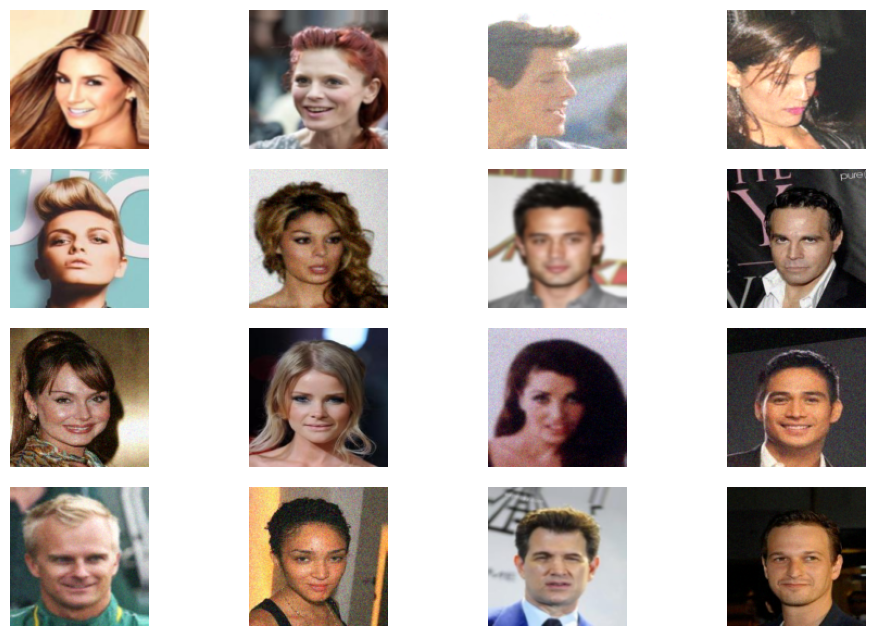

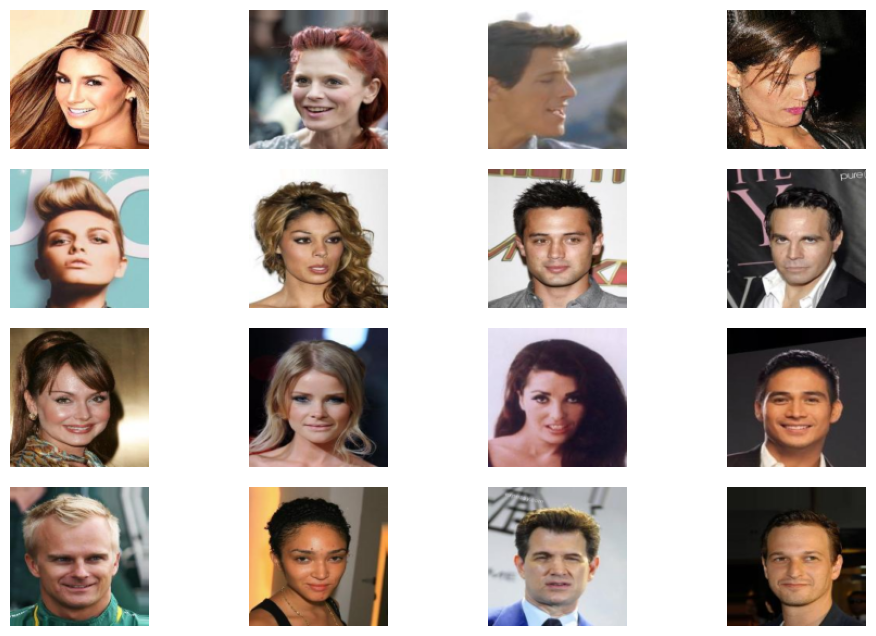

In [33]:
### START CODE HERE ###

batch, gt_img = next(iter(dataloader)) 

imshow_grid(batch)

imshow_grid(gt_img)

### END CODE HERE ###

## Create Autoencoder model
You can design your own Autoencoder model with a customizable number of downsampling and upsampling blocks by passing a list of channel numbers for each layer based on the provided code below. However, please maintain the concept of 'Autoencoder'.

In [54]:
### START CODE HERE ###

class DownSamplingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(DownSamplingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

class UpSamplingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(UpSamplingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.relu = nn.ReLU()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.upsample(x)
        return x

class Autoencoder(nn.Module):
    def __init__(self, architecture=[64, 128, 256, 512]):
        super().__init__()
        self.conv_in = nn.Conv2d(3, architecture[0], kernel_size=3, stride=1, padding=1)
        self.down_blocks = nn.ModuleList()
        in_ch = architecture[0]
        for out_ch in architecture[1:]:
            self.down_blocks.append(DownSamplingBlock(in_ch, out_ch))
            in_ch = out_ch
        self.up_blocks = nn.ModuleList()
        rev_arch = architecture[::-1]
        for i in range(len(rev_arch)-1):
            self.up_blocks.append(UpSamplingBlock(rev_arch[i], rev_arch[i+1]))
        self.conv_out = nn.Conv2d(architecture[0], 3, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        x = self.conv_in(x)

        for down in self.down_blocks:
            x = down(x)
        for up in self.up_blocks:
            x = up(x)

        x = self.conv_out(x)
        return x
    
### END CODE HERE ###

## Train Autoencoder
Complete the `train()` function in the cell below. This function should evaluate the model at every epoch, log the ***training loss, test loss,test PSNR, test SSIM***. Additionally, it should save the model at the last epoch.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The log should resemble this, but not be identical

```
🤖Training on cuda
🚀Training Epoch [1/1]: 100%|██████████| 1313/1313 [01:45<00:00, 12.41batch/s, loss=0.0102] 
📄Testing: 100%|██████████| 563/563 [01:10<00:00,  7.95batch/s, loss=0.0106, psnr=16.7, ssim=0.348] 
Summary :
	Train	avg_loss: 0.017262999383663165
	Test	avg_loss: 0.010476540363861867 
                PSNR : 16.839487147468034 
                SSIM : 0.36090552368883694
...
```

</details>

Resource : [PyTorch Training loop](<https://pytorch.org/tutorials/beginner/introyt/trainingyt.html#:~:text=%3D0.9)-,The%20Training%20Loop,-Below%2C%20we%20have>), [PSNR & SSIM](https://ieeexplore.ieee.org/document/5596999)

In [35]:
### START CODE HERE ###
def train(model, opt, loss_fn, train_loader, test_loader, epochs=10, checkpoint_path=None, device='cpu'):
    print(f"🤖 Training on {device}")
    model = model.to(device)
    
    for epoch in range(epochs):
        model.train()
        train_loss_total = 0.0
        train_bar = tqdm(train_loader, desc=f'🚀 Training Epoch [{epoch+1}/{epochs}]', unit='batch')
        
        for images, gt in train_bar:
            images = images.to(device)
            gt = gt.to(device)
            
            outputs = model(images)
            loss = loss_fn(outputs, gt)
            
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            train_loss_total += loss.item() * images.size(0)
            train_bar.set_postfix({'loss': f"{loss.item():.4f}"})
        
        train_loss = train_loss_total / len(train_loader.dataset)
        
        model.eval()
        test_loss_total = 0.0
        psnr_total = 0.0
        ssim_total = 0.0
        test_bar = tqdm(test_loader, desc='📄 Testing', unit='batch')
        
        with torch.no_grad():
            for images, gt in test_bar:
                images = images.to(device)
                gt = gt.to(device)
                
                outputs = model(images)
                loss = loss_fn(outputs, gt)
                test_loss_total += loss.item() * images.size(0)
                
                outputs_np = outputs.clamp(0,1).cpu().numpy()
                gt_np = gt.clamp(0,1).cpu().numpy()
                
                for i in range(outputs_np.shape[0]):
                    gt_img = gt_np[i].transpose(1,2,0)
                    out_img = outputs_np[i].transpose(1,2,0)
                    win_size = 3 if min(gt_img.shape[:2]) < 7 else 7
                    psnr_total += psnr(gt_img, out_img, data_range=1.0)
                    ssim_total += ssim(gt_img, out_img, channel_axis=2, data_range=1.0, win_size=win_size)
                
                test_bar.set_postfix({
                    'loss': f"{loss.item():.4f}",
                    'psnr': f"{psnr_total/len(test_loader.dataset):.2f}",
                    'ssim': f"{ssim_total/len(test_loader.dataset):.3f}"
                })
        
        test_loss = test_loss_total / len(test_loader.dataset)
        psnr_epoch = psnr_total / len(test_loader.dataset)
        ssim_epoch = ssim_total / len(test_loader.dataset)
        
        print("Summary :")
        print(f"\tTrain\tavg_loss: {train_loss}")
        print(f"\tTest\tavg_loss: {test_loss} ")
        print(f"\t\tPSNR : {psnr_epoch} ")
        print(f"\t\tSSIM : {ssim_epoch} ")
        
        if checkpoint_path and (epoch+1 == epochs):
            torch.save(model.state_dict(), checkpoint_path)
            print(f"✅ Model saved to {checkpoint_path}")

                
### END CODE HERE ###

Let's train your model with 2 epochs to verify that your train() function works properly. After that, we'll move on to the Hyperparameter Grid Search in the next part.

In [36]:
### START CODE HERE ###

data_dir = 'data/img_align_celeba'

files = os.listdir(data_dir)
files = [os.path.join(data_dir, file) for file in files]

sample_size = 100
if len(files) > sample_size:
    files = random.sample(files, sample_size)

train_files, test_files = train_test_split(files, test_size=0.2, random_state=42)

train_dataset = CustomImageDataset(train_files, gauss_noise=True, gauss_blur=True, resize=128, p=0.5)
test_dataset  = CustomImageDataset(test_files, gauss_noise=False, gauss_blur=False, resize=128, p=0.0)
trainloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
testloader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

### END CODE HERE ###

In [ ]:
### START CODE HERE ###

model = Autoencoder()
opt = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

train(
    model=model,
    opt=opt,
    loss_fn=loss_fn,
    train_loader=trainloader,
    test_loader=testloader,
    epochs=2,
    checkpoint_path='autoencoder_test.pth',
    device=device
)  

### END CODE HERE ###

🤖 Training on cpu


📄 Testing: 100%|██████████| 2/2 [00:00<00:00,  2.10batch/s, loss=0.1443, psnr=8.89, ssim=0.169]


Summary :
	Train	avg_loss: 0.2589233636856079
	Test	avg_loss: 0.19603488445281983 
		PSNR : 8.892341945217975 
		SSIM : 0.16937167942523956 


📄 Testing: 100%|██████████| 2/2 [00:00<00:00,  2.04batch/s, loss=0.1234, psnr=9.60, ssim=0.208]

Summary :
	Train	avg_loss: 0.21577630341053008
	Test	avg_loss: 0.1169110968708992 
		PSNR : 9.59869930134708 
		SSIM : 0.20841090381145477 
✅ Model saved to autoencoder.pth


---

## **Hyperparameter Grid Search with Raytune**

*If you have access to APEX, I would recommend converting this part into a Python file and submitting the job to run on APEX using SBATCH. This process may take a considerable amount of time.*

You can import additional Ray Tune tools as you want, such as schedulers, search algorithms, etc. Further information on the usage of Ray Tune can be found [here](https://docs.ray.io/en/latest/tune/index.html).

In [38]:
import ray
from ray import tune
from ray.air import session, RunConfig


ray.shutdown()


Complete the `train_raytune()` function below, following the [quick start guide](https://docs.ray.io/en/latest/tune/index.html). This function will be passed to the `tune.Tuner`.

In [ ]:
### START CODE HERE ###
def train_raytune(config):
    # device = "cuda" if torch.cuda.is_available() else "cpu"

    # data_dir = 'data/img_align_celeba'
    # files = os.listdir(data_dir)
    # files = [os.path.join(data_dir, file) for file in files]

    # if len(files) == 0:
    #     raise RuntimeError(f"No images found in {data_dir}!")

    # train_files, test_files = train_test_split(files, test_size=0.2, random_state=42)

    # train_dataset = CustomImageDataset(train_files, gauss_noise=True, gauss_blur=True, resize=128, p=0.5)
    # test_dataset  = CustomImageDataset(test_files, gauss_noise=False, gauss_blur=False, resize=128, p=0.0)

    # trainloader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    # testloader  = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False)

    x_train = torch.rand(100, 3, 32, 32)   
    y_train = x_train.clone()              
    trainset = TensorDataset(x_train, y_train)
    trainloader = DataLoader(trainset, batch_size=config["batch_size"], shuffle=True)

    x_test = torch.rand(20, 3, 32, 32)
    y_test = x_test.clone()
    testset = TensorDataset(x_test, y_test)
    testloader = DataLoader(testset, batch_size=config["batch_size"], shuffle=False)

    model = Autoencoder().to(device)

    loss_fn = nn.MSELoss()
    if config["optimizer"] == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    elif config["optimizer"] == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=config["lr"], momentum=0.9)
    else:
        raise ValueError("Unknown optimizer")

    for epoch in range(config["num_epochs"]):
        model.train()
        train_loss_total = 0.0
        for xb, yb in trainloader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            optimizer.step()
            train_loss_total += loss.item() * xb.size(0)

        avg_train_loss = train_loss_total / max(len(trainloader.dataset), 1)

        model.eval()
        test_loss_total = 0.0
        psnr_total = 0.0
        ssim_total = 0.0

        with torch.no_grad():
            for xb, yb in testloader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                loss = loss_fn(out, yb)
                test_loss_total += loss.item() * xb.size(0)

                out_np = out.clamp(0, 1).cpu().numpy()
                yb_np = yb.clamp(0, 1).cpu().numpy()

                for i in range(out_np.shape[0]):
                    gt_img = yb_np[i].transpose(1, 2, 0)
                    out_img = out_np[i].transpose(1, 2, 0)
                    win_size = 3 if min(gt_img.shape[:2]) < 7 else 7
                    psnr_total += psnr(gt_img, out_img, data_range=1.0)
                    ssim_total += ssim(gt_img, out_img, channel_axis=2, data_range=1.0, win_size=win_size)

        avg_test_loss = test_loss_total / max(len(testloader.dataset), 1)
        avg_psnr = psnr_total / max(len(testloader.dataset), 1)
        avg_ssim = ssim_total / max(len(testloader.dataset), 1)

        if np.isnan(avg_test_loss) or np.isinf(avg_test_loss):
            avg_test_loss = 1e6
        if np.isnan(avg_psnr) or np.isinf(avg_psnr):
            avg_psnr = 0.0
        if np.isnan(avg_ssim) or np.isinf(avg_ssim):
            avg_ssim = 0.0

        print(f"Epoch {epoch+1}/{config['num_epochs']} - train_loss: {avg_train_loss:.6f}, val_loss: {avg_test_loss:.6f}, val_psnr: {avg_psnr:.4f}, val_ssim: {avg_ssim:.4f}")

        session.report({
            "train_loss": avg_train_loss,
            "val_loss": avg_test_loss,
            "val_psnr": avg_psnr,
            "val_ssim": avg_ssim,
        })

### END CODE HERE ###

Initialize Ray, define the search space, and resources.

Resource : 
- [A Guide To Parallelism and Resources for Ray Tune](https://docs.ray.io/en/latest/tune/tutorials/tune-resources.html#:~:text=A%20Guide%20To%20Parallelism%20and%20Resources%20for%20Ray%20Tune) 
- [Working with Tune Search Spaces](https://docs.ray.io/en/latest/tune/tutorials/tune-search-spaces.html#tune-search-space-tutorial:~:text=Working%20with%20Tune%20Search%20Spaces)
- [How to configure logging in Tune?](https://docs.ray.io/en/latest/tune/tutorials/tune-output.html) 
- [Tune Trial Schedulers (`tune.schedulers`)](https://docs.ray.io/en/latest/tune/api/schedulers.html#tune-scheduler-pbt:~:text=Tune%20Trial...-,Tune%20Trial%20Schedulers%20(tune.schedulers),-%23)

**Search Space:**
- `architecture`:<br>
    Feature map dimensions for convolutional layers<br>
    - `[32, 64, 128]`: 3 downsampling layers with feature maps increasing from 32 to 128.
    - `[64, 128, 256]`: 3 downsampling layers with feature maps starting from 64 to 256.
    - `[64, 128, 256, 512]`: 4 downsampling layers with more depth, starting from 64 and ending at 512.
- `learning rates (lr)`:
    - [1e-3, 8e-4, 1e-4, 1e-2]: Test a wide range of learning rates to evaluate model performance, from 1e-3 (typical) to a more aggressive 1e-2 or conservative 1e-4.
- `batch size`:
    - [16, 32]: Explore smaller batch sizes to evaluate their impact on gradient estimation and memory usage.
- `number of epochs`:
    - `[10, 50, 100]`: Allow short and long training sessions, from quick evaluations (10 epochs) to more extensive training (100 epochs).
- `optimizers (opts)`:
    - `["Adam", "SGD"]`: Compare two popular optimization algorithms: Adam for adaptive learning rates and SGD for momentum-based updates.

In [ ]:
ray.shutdown()
ray.init(num_gpus=1)

search_space = {
    "architecture": tune.choice([
        [32, 64, 128],
        [64, 128, 256],
        [64, 128, 256, 512]
    ]),
    "lr": tune.uniform(1e-4, 1e-2),            
    "batch_size": tune.randint(16, 33),        
    "num_epochs": tune.randint(10, 101), 
    "optimizer": tune.choice(["Adam", "SGD"])
}

tuner = tune.Tuner(
    train_raytune,
    param_space=search_space,
    tune_config=tune.TuneConfig(metric="val_loss", mode="min", num_samples=5),
)

results = tuner.fit()

2025-09-07 03:29:25,416	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\asus\AppData\Local\Temp\ray\session_2025-09-07_03-29-22_060805_5340\artifacts\2025-09-07_03-29-25\train_raytune_2025-09-07_03-29-25\driver_artifacts\train_raytune_2e08b_00000_0_architecture=64_128_256,batch_size=18,lr=0.0066,num_epochs=30,optimizer=SGD_2025-09-07_03-29-25
2025-09-07 03:29:25,419	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\asus\AppData\Local\Temp\ray\session_2025-09-07_03-29-22_060805_5340\artifacts\2025-09-07_03-29-25\train_raytune_2025-09-07_03-29-25\driver_artifacts\train_raytune_2e08b_00000_0_architecture=64_128_256,batch_size=18,lr=0.0066,num_epochs=30,optimizer=SGD_2025-09-07_03-29-25
2025-09-07 03:29:25,423	WARNING trial.py:647 -- The path to the trial log di

(train_raytune pid=24304) Epoch 1/30 - train_loss: 0.307579, val_loss: 0.276175, val_psnr: 5.5891, val_ssim: 0.0027


2025-09-07 03:29:39,838	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\asus\AppData\Local\Temp\ray\session_2025-09-07_03-29-22_060805_5340\artifacts\2025-09-07_03-29-25\train_raytune_2025-09-07_03-29-25\driver_artifacts\train_raytune_2e08b_00002_2_architecture=64_128_256_512,batch_size=32,lr=0.0001,num_epochs=69,optimizer=Adam_2025-09-07_03-29-25
2025-09-07 03:29:39,920	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\asus\AppData\Local\Temp\ray\session_2025-09-07_03-29-22_060805_5340\artifacts\2025-09-07_03-29-25\train_raytune_2025-09-07_03-29-25\driver_artifacts\train_raytune_2e08b_00004_4_architecture=64_128_256,batch_size=32,lr=0.0038,num_epochs=55,optimizer=Adam_2025-09-07_03-29-25
2025-09-07 03:29:40,019	WARNING trial.py:647 -- The path to the trial 

(train_raytune pid=24304) Epoch 2/30 - train_loss: 0.248063, val_loss: 0.202424, val_psnr: 6.9384, val_ssim: 0.0062 [repeated 5x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(train_raytune pid=24304) Epoch 3/30 - train_loss: 0.175121, val_loss: 0.136455, val_psnr: 8.6513, val_ssim: 0.0091 [repeated 5x across cluster]
(train_raytune pid=21680) Epoch 4/96 - train_loss: 0.255682, val_loss: 0.232727, val_psnr: 6.3321, val_ssim: 0.0047 [repeated 5x across cluster]
(train_raytune pid=21680) Epoch 5/96 - train_loss: 0.224203, val_loss: 0.202775, val_psnr: 6.9304, val_ssim: 0.0062 [repeated 5x across cluster]
(train_raytune pid=21680) Epoch 6/96 - train_loss: 0.194967, val_loss: 0.175606, val_psnr: 7.5552, val_ssim: 0.0074 [repeated 5x across cluster]
(train_raytune pid=21680) Epoch 7/96 - train_loss: 0.168680, v

2025-09-07 03:38:24,382	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'C:/Users/asus/ray_results/train_raytune_2025-09-07_03-29-25' in 0.0145s.
2025-09-07 03:38:24,398	INFO tune.py:1041 -- Total run time: 539.01 seconds (538.97 seconds for the tuning loop).


...

(train_raytune pid=28760) Epoch 16/78 - train_loss: 0.096260, val_loss: 0.093810, val_psnr: 10.2780, val_ssim: 0.0102 [repeated 6x across cluster]
(train_raytune pid=26556) Epoch 13/74 - train_loss: 0.083538, val_loss: 0.083478, val_psnr: 10.7850, val_ssim: 0.0108 [repeated 9x across cluster]
(train_raytune pid=28760) Epoch 17/78 - train_loss: 0.094367, val_loss: 0.094289, val_psnr: 10.2561, val_ssim: 0.0104 [repeated 5x across cluster]


(train_raytune pid=7948) c:\Users\asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\train\_internal\session.py:772: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tune.report` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context: https://github.com/ray-project/ray/issues/49454
(train_raytune pid=7948)   _log_deprecation_warning(


(train_raytune pid=26556) Epoch 14/74 - train_loss: 0.083508, val_loss: 0.083489, val_psnr: 10.7844, val_ssim: 0.0108 [repeated 11x across cluster]
(train_raytune pid=28760) Epoch 18/78 - train_loss: 0.092575, val_loss: 0.093597, val_psnr: 10.2882, val_ssim: 0.0108 [repeated 5x across cluster]
(train_raytune pid=26556) Epoch 15/74 - train_loss: 0.083513, val_loss: 0.083488, val_psnr: 10.7845, val_ssim: 0.0108 [repeated 11x across cluster]
(train_raytune pid=2920) Epoch 38/87 - train_loss: 0.087112, val_loss: 0.087369, val_psnr: 10.5867, val_ssim: 0.0113 [repeated 6x across cluster]
(train_raytune pid=26556) Epoch 16/74 - train_loss: 0.083504, val_loss: 0.083467, val_psnr: 10.7855, val_ssim: 0.0108 [repeated 8x across cluster]
(train_raytune pid=2920) Epoch 39/87 - train_loss: 0.087106, val_loss: 0.087364, val_psnr: 10.5870, val_ssim: 0.0113 [repeated 6x across cluster]
(train_raytune pid=26556) Epoch 17/74 - train_loss: 0.083486, val_loss: 0.083450, val_psnr: 10.7864, val_ssim: 0.0108 

(train_raytune pid=3272) c:\Users\asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\train\_internal\session.py:772: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tune.report` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context: https://github.com/ray-project/ray/issues/49454
(train_raytune pid=3272)   _log_deprecation_warning(


(train_raytune pid=3272) Epoch 1/59 - train_loss: 180290538.181455, val_loss: 60671.054688, val_psnr: 4.7978, val_ssim: 0.0000 [repeated 9x across cluster]
(train_raytune pid=2920) Epoch 43/87 - train_loss: 0.087081, val_loss: 0.087339, val_psnr: 10.5882, val_ssim: 0.0113 [repeated 7x across cluster]
(train_raytune pid=26556) Epoch 21/74 - train_loss: 0.083458, val_loss: 0.083419, val_psnr: 10.7880, val_ssim: 0.0108 [repeated 9x across cluster]
(train_raytune pid=2920) Epoch 44/87 - train_loss: 0.087074, val_loss: 0.087333, val_psnr: 10.5885, val_ssim: 0.0113 [repeated 7x across cluster]
(train_raytune pid=26556) Epoch 22/74 - train_loss: 0.083452, val_loss: 0.083414, val_psnr: 10.7883, val_ssim: 0.0108 [repeated 9x across cluster]
(train_raytune pid=2920) Epoch 45/87 - train_loss: 0.087068, val_loss: 0.087327, val_psnr: 10.5888, val_ssim: 0.0113 [repeated 7x across cluster]
(train_raytune pid=26556) Epoch 23/74 - train_loss: 0.083447, val_loss: 0.083408, val_psnr: 10.7886, val_ssim: 0

Restore the result from path of ray resule directory

In [50]:
### START CODE HERE ###

# tuner.save("my_tuner")
restored_tuner = tune.Tuner.restore("C:/Users/asus/ray_results/train_raytune_2025-09-07_03-29-25", trainable='train_raytune')
# results = tune.Analysis("C:/Users/asus/ray_results/train_raytune_2025-09-07_03-29-25")

### END CODE HERE ###

Get the report from Grid Search to CSV file.

In [52]:
print("🎉[INFO] Training is done!")
print("Best config is:", results.get_best_result().config)
print("Best result is:", results.get_best_result())
df = results.get_dataframe()

# print(results.get_best_result())

🎉[INFO] Training is done!
Best config is: {'architecture': [64, 128, 256, 512], 'lr': 0.00011600359152807535, 'batch_size': 32, 'num_epochs': 69, 'optimizer': 'Adam'}
Best result is: Result(
  metrics={'train_loss': 0.08306676417589187, 'val_loss': 0.08311863988637924, 'val_psnr': np.float64(10.803805091399495), 'val_ssim': np.float32(0.01080942)},
  path='C:/Users/asus/ray_results/train_raytune_2025-09-07_03-29-25/train_raytune_2e08b_00002_2_architecture=64_128_256_512,batch_size=32,lr=0.0001,num_epochs=69,optimizer=Adam_2025-09-07_03-29-25',
  filesystem='local',
  checkpoint=None
)


---

Train the Autoencoder models using the best hyperparameter set obtained from the grid search.

In [ ]:
### START CODE HERE ###

best_config = results.get_best_result(metric="val_loss", mode="min").config
trainloader = DataLoader(
    train_dataset,
    batch_size=best_config["batch_size"],
    shuffle=True
)
testloader = DataLoader(
    test_dataset,
    batch_size=best_config["batch_size"],
    shuffle=False
)

model = Autoencoder(best_config["architecture"])

if best_config["optimizer"] == "Adam":
    opt = optim.Adam(model.parameters(), lr=best_config["lr"])
elif best_config["optimizer"] == "SGD":
    opt = optim.SGD(model.parameters(), lr=best_config["lr"], momentum=0.9)

loss_fn = nn.MSELoss()

device = "cuda" if torch.cuda.is_available() else "cpu"

train(
    model=model,
    opt=opt,
    loss_fn=loss_fn,
    train_loader=trainloader,
    test_loader=testloader,
    epochs=best_config["num_epochs"],
    checkpoint_path="autoencoder_grid_search.pth",
    device=device
)

### END CODE HERE ###

🤖 Training on cpu


📄 Testing: 100%|██████████| 1/1 [00:00<00:00,  1.24batch/s, loss=0.2564, psnr=6.44, ssim=0.067]


Summary :
	Train	avg_loss: 0.30196860432624817
	Test	avg_loss: 0.2563961148262024 
		PSNR : 6.440664198657113 
		SSIM : 0.06650377810001373 


📄 Testing: 100%|██████████| 1/1 [00:00<00:00,  1.26batch/s, loss=0.1760, psnr=8.12, ssim=0.223]


Summary :
	Train	avg_loss: 0.266582790017128
	Test	avg_loss: 0.1760149747133255 
		PSNR : 8.119393086808959 
		SSIM : 0.22343643009662628 


...

Summary :
	Train	avg_loss: 0.016206080466508864
	Test	avg_loss: 0.011687573976814747 
		PSNR : 19.664446532173123 
		SSIM : 0.5242897868156433 


📄 Testing: 100%|██████████| 1/1 [00:01<00:00,  1.12s/batch, loss=0.0122, psnr=19.45, ssim=0.521]


Summary :
	Train	avg_loss: 0.015811224281787873
	Test	avg_loss: 0.01218844298273325 
		PSNR : 19.446830154092275 
		SSIM : 0.5209102630615234 


📄 Testing: 100%|██████████| 1/1 [00:01<00:00,  1.16s/batch, loss=0.0115, psnr=19.71, ssim=0.526]

Summary :
	Train	avg_loss: 0.016695054620504378
	Test	avg_loss: 0.011549768969416618 
		PSNR : 19.710438107977545 
		SSIM : 0.5263771414756775 
✅ Model saved to autoencoder_best.pth


Use the `FeatureExtractor()` class and `visualize_feature_map()` function to visualize the feature map of ***ALL*** layers. Then, save it as an image.


In [ ]:
import math

class FeatureMapVisualizer:
    def __init__(self, model, target_layers, save_dir):
        self.model = model
        self.target_layers = target_layers
        self.features = {}
        self.save_dir = save_dir
        os.makedirs(self.save_dir, exist_ok=True)

        for name, layer in self.model.named_modules():
            if name in self.target_layers:
                layer.register_forward_hook(self._hook_fn(name))

    def _hook_fn(self, layer_name):
        def hook(module, input, output):
            self.features[layer_name] = output.detach()
        return hook

    def visualize_from_loader(self, dataloader, num_images=1, base_filename="feat"):
        device = next(self.model.parameters()).device
        batch, _ = next(iter(dataloader))
        batch = batch[:num_images].to(device)

        self.features = {}
        _ = self.model(batch)

        for layer_idx, (layer_name, feat) in enumerate(self.features.items()):
            for img_idx in range(feat.shape[0]):
                fm = feat[img_idx].cpu()
                n_channels = fm.shape[0]
                n_cols = 12
                n_rows = math.ceil(n_channels / n_cols)

                fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))
                axes = axes.flatten()

                for i in range(n_rows * n_cols):
                    ax = axes[i]
                    if i < n_channels:
                        channel_map = fm[i]
                        channel_map = (channel_map - channel_map.min()) / (channel_map.max() - channel_map.min() + 1e-6)
                        ax.imshow(channel_map, cmap='gray')
                        ax.set_title(f'ch{i+1}', fontsize=8)
                    ax.axis('off')

                plt.tight_layout()
                save_path = os.path.join(self.save_dir, f"{base_filename}_layer{layer_idx+1}_{layer_name}.png")
                plt.savefig(save_path)
                plt.close()
                print(f"✅ Saved feature map: {save_path}")
        
### END CODE HERE ###

In [ ]:
### START CODE HERE ###

target_layers = []
for layer_name, layer in model.named_modules():
    if layer_name == 'conv_in' or layer_name == 'conv_out' or 'upsample' in layer_name or 'pool' in layer_name:
        target_layers.append(layer_name)
print(target_layers)

visualizer = FeatureMapVisualizer(model, target_layers, save_dir="grid_test_feature_maps")

visualizer.visualize_from_loader(trainloader, num_images=1, base_filename="autoencoder")

### END CODE HERE ###

['conv_in', 'down_blocks.0.pool', 'down_blocks.1.pool', 'down_blocks.2.pool', 'up_blocks.0.upsample', 'up_blocks.1.upsample', 'up_blocks.2.upsample', 'conv_out']
✅ Saved feature map: feature_maps\autoencoder_layer1_conv_in.png
✅ Saved feature map: feature_maps\autoencoder_layer2_down_blocks.0.pool.png
✅ Saved feature map: feature_maps\autoencoder_layer3_down_blocks.1.pool.png
✅ Saved feature map: feature_maps\autoencoder_layer4_down_blocks.2.pool.png
✅ Saved feature map: feature_maps\autoencoder_layer5_up_blocks.0.upsample.png
✅ Saved feature map: feature_maps\autoencoder_layer6_up_blocks.1.upsample.png
✅ Saved feature map: feature_maps\autoencoder_layer7_up_blocks.2.upsample.png
✅ Saved feature map: feature_maps\autoencoder_layer8_conv_out.png


---
## **Hyperparameter Random Search with Raytune**

**Search Space:**

- **`architecture`:**  
    Define the feature map dimensions for convolutional layers:  
    - `[32, 64, 128]`: 3 downsampling layers with feature maps increasing from 32 to 128.
    - `[64, 128, 256]`: 3 downsampling layers with feature maps starting from 64 to 256.
    - `[64, 128, 256, 512]`: 4 downsampling layers with additional depth, starting from 64 and ending at 512.
  
- **`learning rates (lr)`**:  
    A continuous range of learning rates sampled uniformly between `1e-4` and `1e-2`. This allows exploration of different learning rates from conservative (`1e-4`) to more aggressive (`1e-2`) values.

- **`batch size`**:  
    Randomly sample an integer batch size between 16 and 32 (inclusive). This allows testing of smaller batch sizes, which can affect gradient estimation and memory usage.

- **`number of epochs`**:  
    Randomly sample an integer number of epochs between 10 and 100. This allows the model to train for short (e.g., 10 epochs) or extended periods (up to 100 epochs), giving insight into model performance over different training durations.

- **`optimizers (opts)`**:  
    Randomly select between two optimizers:  
    - `"Adam"`: An adaptive learning rate optimizer that generally performs well across various tasks.  
    - `"SGD"`: Stochastic Gradient Descent with momentum, commonly used for large-scale tasks, requiring careful tuning of the learning rate.

***NOTE*** Random search with 80 samples.

In [59]:
### START CODE HERE ###

search_space = {
    "architecture": tune.choice([
        [32, 64, 128],
        [64, 128, 256],
        [64, 128, 256, 512]
    ]),
    "lr": tune.uniform(1e-4, 1e-2),
    "batch_size": tune.randint(16, 33),
    "num_epochs": tune.randint(10, 101),
    "optimizer": tune.choice(["Adam", "SGD"])
}

tuner = tune.Tuner(
    train_raytune, 
    param_space=search_space,
    tune_config=tune.TuneConfig(
        num_samples=80,
        metric="val_loss",
        mode="min"
    )
)

results = tuner.fit()

### END CODE HERE ###

2025-09-07 04:12:41,769	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\asus\AppData\Local\Temp\ray\session_2025-09-07_03-29-22_060805_5340\artifacts\2025-09-07_04-12-41\train_raytune_2025-09-07_04-12-41\driver_artifacts\train_raytune_397f3_00000_0_architecture=64_128_256,batch_size=32,lr=0.0066,num_epochs=84,optimizer=Adam_2025-09-07_04-12-41
2025-09-07 04:12:41,774	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\asus\AppData\Local\Temp\ray\session_2025-09-07_03-29-22_060805_5340\artifacts\2025-09-07_04-12-41\train_raytune_2025-09-07_04-12-41\driver_artifacts\train_raytune_397f3_00000_0_architecture=64_128_256,batch_size=32,lr=0.0066,num_epochs=84,optimizer=Adam_2025-09-07_04-12-41
2025-09-07 04:12:41,777	WARNING trial.py:647 -- The path to the trial log 

In [60]:
print("🎉[INFO] Training is done!")
print("Best config is:", results.get_best_result().config)
print("Best result is:", results.get_best_result())
df = results.get_dataframe()
df.to_csv('Random Search', index=False)

# ray.shutdown()

🎉[INFO] Training is done!
Best config is: {'architecture': [64, 128, 256, 512], 'lr': 0.0011789374425291385, 'batch_size': 17, 'num_epochs': 56, 'optimizer': 'Adam'}
Best result is: Result(
  metrics={'train_loss': 0.08335444934666157, 'val_loss': 0.0824376478791237, 'val_psnr': np.float64(10.839237864352924), 'val_ssim': np.float32(0.011177801)},
  path='C:/Users/asus/ray_results/train_raytune_2025-09-07_04-12-41/train_raytune_397f3_00022_22_architecture=64_128_256_512,batch_size=17,lr=0.0012,num_epochs=56,optimizer=Adam_2025-09-07_04-12-41',
  filesystem='local',
  checkpoint=None
)


---

Train the Autoencoder models using the best hyperparameter set obtained from the random search.

In [ ]:
### START CODE HERE ###

best_config = results.get_best_result(metric="val_loss", mode="min").config
trainloader = DataLoader(
    train_dataset,
    batch_size=best_config["batch_size"],
    shuffle=True
)
testloader = DataLoader(
    test_dataset,
    batch_size=best_config["batch_size"],
    shuffle=False
)

model = Autoencoder(best_config["architecture"])

if best_config["optimizer"] == "Adam":
    opt = optim.Adam(model.parameters(), lr=best_config["lr"])
elif best_config["optimizer"] == "SGD":
    opt = optim.SGD(model.parameters(), lr=best_config["lr"], momentum=0.9)

loss_fn = nn.MSELoss()

device = "cuda" if torch.cuda.is_available() else "cpu"

train(
    model=model,
    opt=opt,
    loss_fn=loss_fn,
    train_loader=trainloader,
    test_loader=testloader,
    epochs=best_config["num_epochs"],
    checkpoint_path="autoencoder_random_search.pth",
    device=device
)

### END CODE HERE ###

🤖 Training on cpu


📄 Testing: 100%|██████████| 2/2 [00:00<00:00,  2.43batch/s, loss=0.1823, psnr=6.29, ssim=0.040]


Summary :
	Train	avg_loss: 39.27636433253065
	Test	avg_loss: 0.2653729520738125 
		PSNR : 6.294281583839878 
		SSIM : 0.04008433595299721 


📄 Testing: 100%|██████████| 2/2 [00:00<00:00,  2.45batch/s, loss=0.1824, psnr=6.29, ssim=0.042]


Summary :
	Train	avg_loss: 0.2946452535688877
	Test	avg_loss: 0.26555735915899276 
		PSNR : 6.291757614714055 
		SSIM : 0.04236007109284401 


...

Summary :
	Train	avg_loss: 0.015940852276980878
	Test	avg_loss: 0.013471571216359734 
		PSNR : 18.995553174577708 
		SSIM : 0.5052384734153748 


📄 Testing: 100%|██████████| 2/2 [00:01<00:00,  1.68batch/s, loss=0.0115, psnr=19.09, ssim=0.508]


Summary :
	Train	avg_loss: 0.01801441495772451
	Test	avg_loss: 0.012955276761204004 
		PSNR : 19.09006894606059 
		SSIM : 0.507548987865448 


📄 Testing: 100%|██████████| 2/2 [00:01<00:00,  1.65batch/s, loss=0.0113, psnr=18.93, ssim=0.515]

Summary :
	Train	avg_loss: 0.018942102475557478
	Test	avg_loss: 0.013647648692131042 
		PSNR : 18.931356186005623 
		SSIM : 0.5147706270217896 
✅ Model saved to autoencoder_best.pth


Use the `FeatureExtractor()` class and `visualize_feature_map()` function to visualize the feature map of ***ALL*** layers of the Convolution Feature Extractor part. Then, save it as an image.

In [ ]:
### START CODE HERE ###

target_layers = []
for layer_name, layer in model.named_modules():
    if layer_name == 'conv_in' or layer_name == 'conv_out' or 'upsample' in layer_name or 'pool' in layer_name:
        target_layers.append(layer_name)
print(target_layers)

visualizer = FeatureMapVisualizer(model, target_layers, save_dir="random_test_feature_maps")

visualizer.visualize_from_loader(trainloader, num_images=1, base_filename="autoencoder")

### END CODE HERE ###

✅ Saved feature map: feature_maps\autoencoder_conv_in_img1.png
✅ Saved feature map: feature_maps\autoencoder_down1_img1.png
✅ Saved feature map: feature_maps\autoencoder_down2_img1.png
✅ Saved feature map: feature_maps\autoencoder_down3_img1.png
✅ Saved feature map: feature_maps\autoencoder_down4_img1.png
✅ Saved feature map: feature_maps\autoencoder_up4_img1.png
✅ Saved feature map: feature_maps\autoencoder_up3_img1.png
✅ Saved feature map: feature_maps\autoencoder_up2_img1.png
✅ Saved feature map: feature_maps\autoencoder_up1_img1.png


---

# Questions

1. How many combinations of hyperparameter values (trials) were evaluated during the hyperparameter tuning process?
2. What are the top 3 best parameters and their corresponding tuning results for the model?
3. Analyze and compare the similarities and differences between the top 3 parameters in terms of model architecture, loss, performance, etc.


